# Proyecto Centinela · Fase 2 — Rama B: Serie Temporal con LSTM, GRU y RNN
### Predicción del retorno diario de la TRM (Tasa de Cambio Representativa del Mercado)

**Autores:** Estefanny Ruíz González · Miguel Alarcón Ojeda
**Curso:** Profundización I — Redes Neuronales / Deep Learning (EA-N-F-004)
**Maestría en Ciencia de Datos — Universidad Santo Tomás**

---

**Problema:** predecir el **retorno porcentual** de la TRM del día siguiente
(cuánto sube o baja en porcentaje), usando tres arquitecturas recurrentes:
RNN simple, LSTM y GRU.

**¿Por qué retornos y no el nivel absoluto?**
La TRM absoluta tiene una deriva de largo plazo (~1.874 pesos en 2000 → ~3.350
en 2026). Si escalamos el nivel, el scaler entrenado con datos hasta 2018 no
conoce los valores de 2022–2026 (que llegaron a 5.061 pesos), generando
extrapolación severa. Los **retornos porcentuales diarios** son estacionarios
(siempre oscilan cerca de 0%) y resuelven este problema sin pérdida de
información relevante.

**Fuente:** Datos Abiertos Colombia / Superintendencia Financiera de Colombia.
Serie diaria desde enero 2000 (6.307 retornos utilizables).


## 0. Preparación del entorno

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEMILLA  = 42
WINDOW   = 30    # días de historia que ve el modelo
EPOCAS   = 100
LR       = 0.001
PACIENCIA = 15   # early stopping

np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
print("PyTorch:", torch.__version__)
print("Semilla fija:", SEMILLA)


PyTorch: 2.11.0+cpu
Semilla fija: 42


## 1. Carga de datos y EDA

> **En Colab:** sube `trm_diaria_limpia.csv` antes de ejecutar esta celda.


In [3]:
from google.colab import files
subido = files.upload()


In [5]:
df = pd.read_csv("trm_diaria_limpia.csv", parse_dates=["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

print("Filas:", len(df))
print("Rango:", df["fecha"].min().date(), "->", df["fecha"].max().date())
df.head()


Filas: 6308
Rango: 2000-01-04 -> 2026-07-07


,fecha,trm
0,2000-01-04,1874.35
1,2000-01-05,1895.97
2,2000-01-06,1912.69
3,2000-01-07,1911.33
4,2000-01-08,1900.14


In [6]:
# Calcular retorno porcentual diario
df["retorno"] = df["trm"].pct_change() * 100
df = df.dropna(subset=["retorno"]).reset_index(drop=True)

print("Filas con retorno:", len(df))
print()
print("Estadísticas del retorno diario (%):")
print(df["retorno"].describe().round(4))


Filas con retorno: 6307

Estadísticas del retorno diario (%):
count    6307.0000
mean        0.0119
std         0.7337
min        -5.4668
25%        -0.3515
50%        -0.0061
75%         0.3614
max         6.1101
Name: retorno, dtype: float64


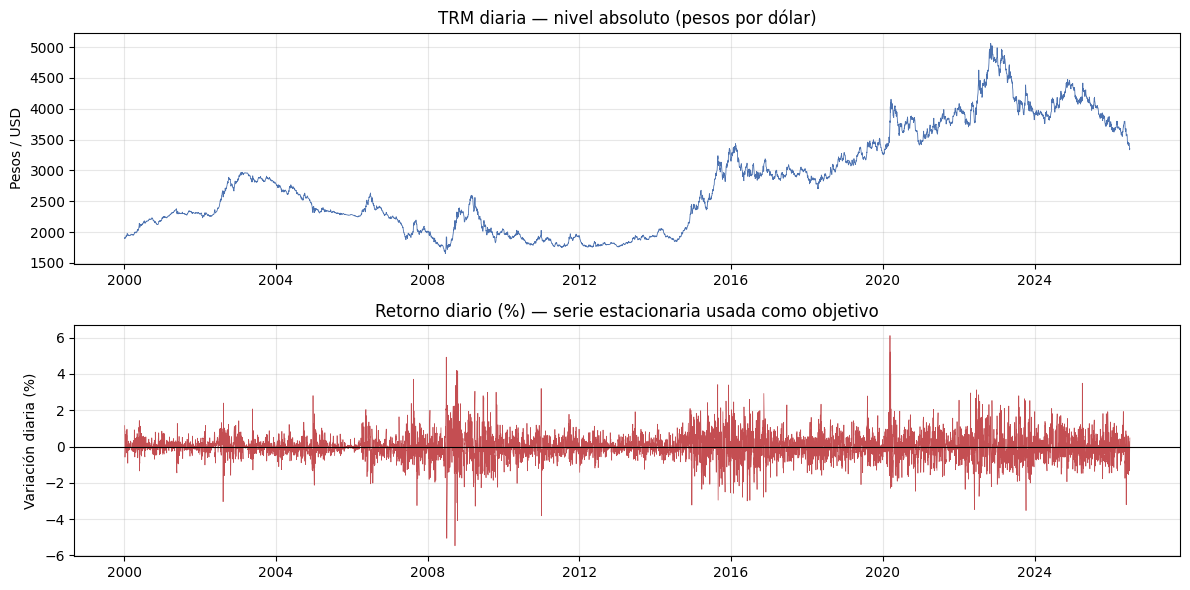

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

# TRM en nivel
axes[0].plot(df["fecha"], df["trm"], color="#4C72B0", linewidth=0.6)
axes[0].set_title("TRM diaria — nivel absoluto (pesos por dólar)")
axes[0].set_ylabel("Pesos / USD")
axes[0].grid(alpha=0.3)

# Retorno diario
axes[1].plot(df["fecha"], df["retorno"], color="#C44E52", linewidth=0.5)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Retorno diario (%) — serie estacionaria usada como objetivo")
axes[1].set_ylabel("Variación diaria (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Hallazgo del EDA — por qué usamos retornos:**
La TRM en nivel (gráfica superior) tiene una **tendencia creciente de largo
plazo** — esto hace que el scaler entrenado con datos históricos falle al
proyectarse al período de test, donde los valores son sistemáticamente más altos.

El retorno diario (gráfica inferior) es **estacionario**: oscila alrededor de
0% sin tendencia, con un rango estable de aproximadamente −5.5% a +6.1% a lo
largo de todo el período 2000–2026. Esto garantiza que el scaler generaliza
correctamente.


## 2. Preprocesamiento: escalado y ventana deslizante

In [8]:
# Partición cronológica ANTES de escalar
vals = df["retorno"].values.reshape(-1, 1)
n = len(vals)
i_tr = int(n * 0.70)
i_va = int(n * 0.85)

raw_train = vals[:i_tr]
raw_val   = vals[i_tr:i_va]
raw_test  = vals[i_va:]

print(f"Filas -> train: {len(raw_train)} | val: {len(raw_val)} | test: {len(raw_test)}")
print(f"Período train: {df['fecha'][0].date()} -> {df['fecha'][i_tr-1].date()}")
print(f"Período val  : {df['fecha'][i_tr].date()} -> {df['fecha'][i_va-1].date()}")
print(f"Período test : {df['fecha'][i_va].date()} -> {df['fecha'].iloc[-1].date()}")


Filas -> train: 4414 | val: 946 | test: 947
Período train: 2000-01-05 -> 2018-07-11
Período val  : 2018-07-12 -> 2022-06-29
Período test : 2022-06-30 -> 2026-07-07


In [9]:
# Escalado: fit SOLO en train
scaler = MinMaxScaler()
train_sc = scaler.fit_transform(raw_train)
val_sc   = scaler.transform(raw_val)
test_sc  = scaler.transform(raw_test)

print(f"Train escalado: min={train_sc.min():.3f}  max={train_sc.max():.3f}")
print(f"Val   escalado: min={val_sc.min():.3f}  max={val_sc.max():.3f}")
print(f"Test  escalado: min={test_sc.min():.3f}  max={test_sc.max():.3f}")
print()
vals_fuera_val  = ((val_sc < 0) | (val_sc > 1)).sum()
vals_fuera_test = ((test_sc < 0) | (test_sc > 1)).sum()
print(f"Valores fuera de [0,1] en val : {vals_fuera_val} (esperado: pocos)")
print(f"Valores fuera de [0,1] en test: {vals_fuera_test} (esperado: cero)")


Train escalado: min=0.000  max=1.000
Val   escalado: min=0.192  max=1.114
Test  escalado: min=0.187  max=0.862

Valores fuera de [0,1] en val : 2 (esperado: pocos)
Valores fuera de [0,1] en test: 0 (esperado: cero)


In [10]:
# Ventana deslizante
def crear_ventanas(serie, window):
    """
    Entrada: ventana de 'window' retornos consecutivos
    Objetivo: retorno del día siguiente
    """
    X, y = [], []
    for i in range(window, len(serie)):
        X.append(serie[i-window:i, 0])
        y.append(serie[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = crear_ventanas(train_sc, WINDOW)
X_val,   y_val   = crear_ventanas(val_sc,   WINDOW)
X_test,  y_test  = crear_ventanas(test_sc,  WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}    y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")


X_train: (4384, 30)  y_train: (4384,)
X_val  : (916, 30)    y_val  : (916,)
X_test : (917, 30)   y_test : (917,)


In [11]:
# Convertir a tensores — forma (batch, seq_len, features)
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32).unsqueeze(-1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).view(-1, 1)

print("Tensores listos:")
print(f"  X_train: {tuple(X_train_t.shape)}")
print(f"  y_train: {tuple(y_train_t.shape)}")


Tensores listos:
  X_train: (4384, 30, 1)
  y_train: (4384, 1)


## 3. Arquitecturas: RNN simple, LSTM y GRU

Las tres comparten la misma estructura base para comparar en igualdad
de condiciones (mismos hiperparámetros, misma semilla).

| Arquitectura | Puertas | Ventaja |
|---|---|---|
| RNN simple | Ninguna | Referencia para mostrar el desvanecimiento del gradiente |
| LSTM | 3 (olvido, entrada, salida) | Memoria de largo plazo robusta |
| GRU | 2 (reinicio, actualización) | Más eficiente, similar desempeño con datos moderados |


In [12]:
class ModeloRecurrente(nn.Module):
    def __init__(self, tipo="LSTM", input_size=1, hidden_size=64,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.tipo = tipo
        cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[tipo]
        self.rnn = cls(input_size, hidden_size, num_layers,
                       batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])  # solo el último paso temporal

# Verificar parámetros de cada arquitectura
for tipo in ["RNN", "LSTM", "GRU"]:
    m = ModeloRecurrente(tipo=tipo)
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{tipo:4s}: {params:,} parámetros entrenables")


RNN : 12,673 parámetros entrenables
LSTM: 50,497 parámetros entrenables
GRU : 37,889 parámetros entrenables


## 4. Entrenamiento con Early Stopping

In [13]:
def entrenar_modelo(tipo, X_tr, y_tr, X_va, y_va,
                    epocas=EPOCAS, lr=LR, paciencia=PACIENCIA):
    torch.manual_seed(SEMILLA)
    modelo = ModeloRecurrente(tipo=tipo)
    criterio = nn.MSELoss()
    optim = torch.optim.Adam(modelo.parameters(), lr=lr)

    mejor_val  = float("inf")
    sin_mejora = 0
    mejor_pesos = None
    hist_train, hist_val = [], []

    for epoca in range(epocas):
        modelo.train()
        optim.zero_grad()
        pred = modelo(X_tr)
        loss = criterio(pred, y_tr)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
        optim.step()

        modelo.eval()
        with torch.no_grad():
            loss_val = criterio(modelo(X_va), y_va)

        hist_train.append(loss.item())
        hist_val.append(loss_val.item())

        if loss_val.item() < mejor_val - 1e-6:
            mejor_val   = loss_val.item()
            sin_mejora  = 0
            mejor_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                print(f"  Early stopping en época {epoca} "
                      f"(val no mejoró en {paciencia} épocas)")
                break

        if epoca % 20 == 0:
            print(f"  Época {epoca:3d} | "
                  f"train: {loss.item():.6f} | val: {loss_val.item():.6f}")

    modelo.load_state_dict(mejor_pesos)
    return modelo, hist_train, hist_val


In [14]:
resultados = {}

for tipo in ["RNN", "LSTM", "GRU"]:
    print(f"\n=== Entrenando {tipo} ===")
    modelo, ht, hv = entrenar_modelo(
        tipo, X_train_t, y_train_t, X_val_t, y_val_t)
    resultados[tipo] = {"modelo": modelo, "hist_train": ht, "hist_val": hv}
    print(f"  Mejor val MSE: {min(hv):.6f}")



=== Entrenando RNN ===
  Época   0 | train: 0.456941 | val: 0.310646
  Early stopping en época 19 (val no mejoró en 15 épocas)
  Mejor val MSE: 0.005921

=== Entrenando LSTM ===
  Época   0 | train: 0.399921 | val: 0.370953
  Época  20 | train: 0.008210 | val: 0.006184
  Época  40 | train: 0.006626 | val: 0.008027
  Early stopping en época 50 (val no mejoró en 15 épocas)
  Mejor val MSE: 0.005937

=== Entrenando GRU ===
  Época   0 | train: 0.257707 | val: 0.212536
  Época  20 | train: 0.005340 | val: 0.008170
  Época  40 | train: 0.005773 | val: 0.006746
  Early stopping en época 60 (val no mejoró en 15 épocas)
  Mejor val MSE: 0.005918


## 5. Curvas de pérdida

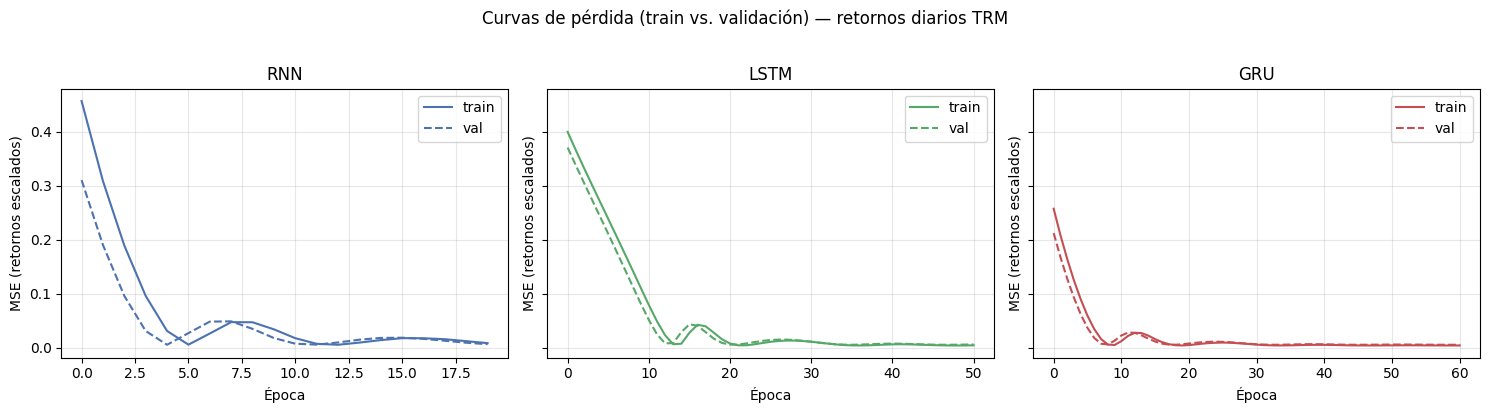

In [15]:
colores = {"RNN": "#4C72B0", "LSTM": "#55A868", "GRU": "#C44E52"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, tipo in zip(axes, ["RNN", "LSTM", "GRU"]):
    ht = resultados[tipo]["hist_train"]
    hv = resultados[tipo]["hist_val"]
    ax.plot(ht, label="train", color=colores[tipo])
    ax.plot(hv, label="val",   color=colores[tipo], linestyle="--")
    ax.set_title(f"{tipo}")
    ax.set_xlabel("Época")
    ax.set_ylabel("MSE (retornos escalados)")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Curvas de pérdida (train vs. validación) — retornos diarios TRM",
             y=1.02)
plt.tight_layout()
plt.show()


## 6. Evidencia del desvanecimiento del gradiente

El **desvanecimiento del gradiente** ocurre cuando, al propagar el error hacia
atrás en el tiempo, los gradientes se multiplican por valores pequeños
repetidamente hasta volverse casi cero. Esto impide que la RNN aprenda
dependencias de largo plazo (eventos de hace muchos pasos no influyen en el
aprendizaje).

Comparamos la norma del gradiente de la primera capa recurrente durante el
entrenamiento de RNN vs. LSTM. Si la RNN colapsa hacia cero mientras el LSTM
se mantiene estable, es evidencia directa del fenómeno.


Calculando normas de gradiente...


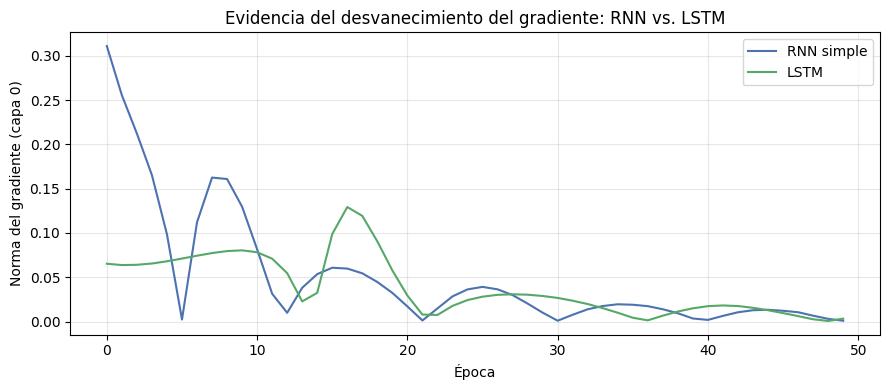


Norma final RNN : 0.000913
Norma final LSTM: 0.003216


In [16]:
def normas_gradiente(tipo, epocas=50):
    torch.manual_seed(SEMILLA)
    m = ModeloRecurrente(tipo=tipo)
    opt = torch.optim.Adam(m.parameters(), lr=LR)
    crit = nn.MSELoss()
    normas = []
    for _ in range(epocas):
        m.train(); opt.zero_grad()
        loss = crit(m(X_train_t), y_train_t)
        loss.backward()
        norma = m.rnn.weight_ih_l0.grad.norm().item()
        normas.append(norma)
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
    return normas

print("Calculando normas de gradiente...")
normas_rnn  = normas_gradiente("RNN",  epocas=50)
normas_lstm = normas_gradiente("LSTM", epocas=50)

plt.figure(figsize=(9, 4))
plt.plot(normas_rnn,  label="RNN simple", color="#4C72B0")
plt.plot(normas_lstm, label="LSTM",       color="#55A868")
plt.xlabel("Época")
plt.ylabel("Norma del gradiente (capa 0)")
plt.title("Evidencia del desvanecimiento del gradiente: RNN vs. LSTM")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nNorma final RNN : {normas_rnn[-1]:.6f}")
print(f"Norma final LSTM: {normas_lstm[-1]:.6f}")


## 7. Evaluación en test

In [17]:
def evaluar(modelo, X_t, y_t, scaler, nombre="test"):
    modelo.eval()
    with torch.no_grad():
        pred_sc = modelo(X_t).numpy()
        real_sc = y_t.numpy()

    # Desnormalizar a retornos reales (%)
    pred = scaler.inverse_transform(pred_sc)
    real = scaler.inverse_transform(real_sc)

    rmse = np.sqrt(mean_squared_error(real, pred))
    mae  = mean_absolute_error(real, pred)
    # MAPE solo donde real != 0 y es razonable
    mask = np.abs(real) > 0.01
    mape = np.mean(np.abs((real[mask] - pred[mask]) / real[mask])) * 100

    print(f"=== {nombre} ===")
    print(f"  RMSE : {rmse:.4f} %")
    print(f"  MAE  : {mae:.4f} %")
    print(f"  MAPE : {mape:.2f} %")
    return pred, real, {"RMSE": rmse, "MAE": mae, "MAPE": mape}

metricas      = {}
predicciones  = {}

for tipo in ["RNN", "LSTM", "GRU"]:
    pred, real, m = evaluar(
        resultados[tipo]["modelo"], X_test_t, y_test_t, scaler, tipo)
    metricas[tipo]     = m
    predicciones[tipo] = (pred, real)
    print()


=== RNN ===
  RMSE : 0.8342 %
  MAE  : 0.6416 %
  MAPE : 103.17 %

=== LSTM ===
  RMSE : 0.8349 %
  MAE  : 0.6453 %
  MAPE : 105.71 %

=== GRU ===
  RMSE : 0.8343 %
  MAE  : 0.6435 %
  MAPE : 103.94 %



In [18]:
# Tabla comparativa
print("=== TABLA COMPARATIVA ===")
print(f"{'Modelo':<8} {'RMSE (%)':>12} {'MAE (%)':>12} {'MAPE (%)':>12}")
print("-" * 48)
for tipo in ["RNN", "LSTM", "GRU"]:
    m = metricas[tipo]
    print(f"{tipo:<8} {m['RMSE']:>12.4f} {m['MAE']:>12.4f} {m['MAPE']:>11.2f}%")


=== TABLA COMPARATIVA ===
Modelo       RMSE (%)      MAE (%)     MAPE (%)
------------------------------------------------
RNN            0.8342       0.6416      103.17%
LSTM           0.8349       0.6453      105.71%
GRU            0.8343       0.6435      103.94%


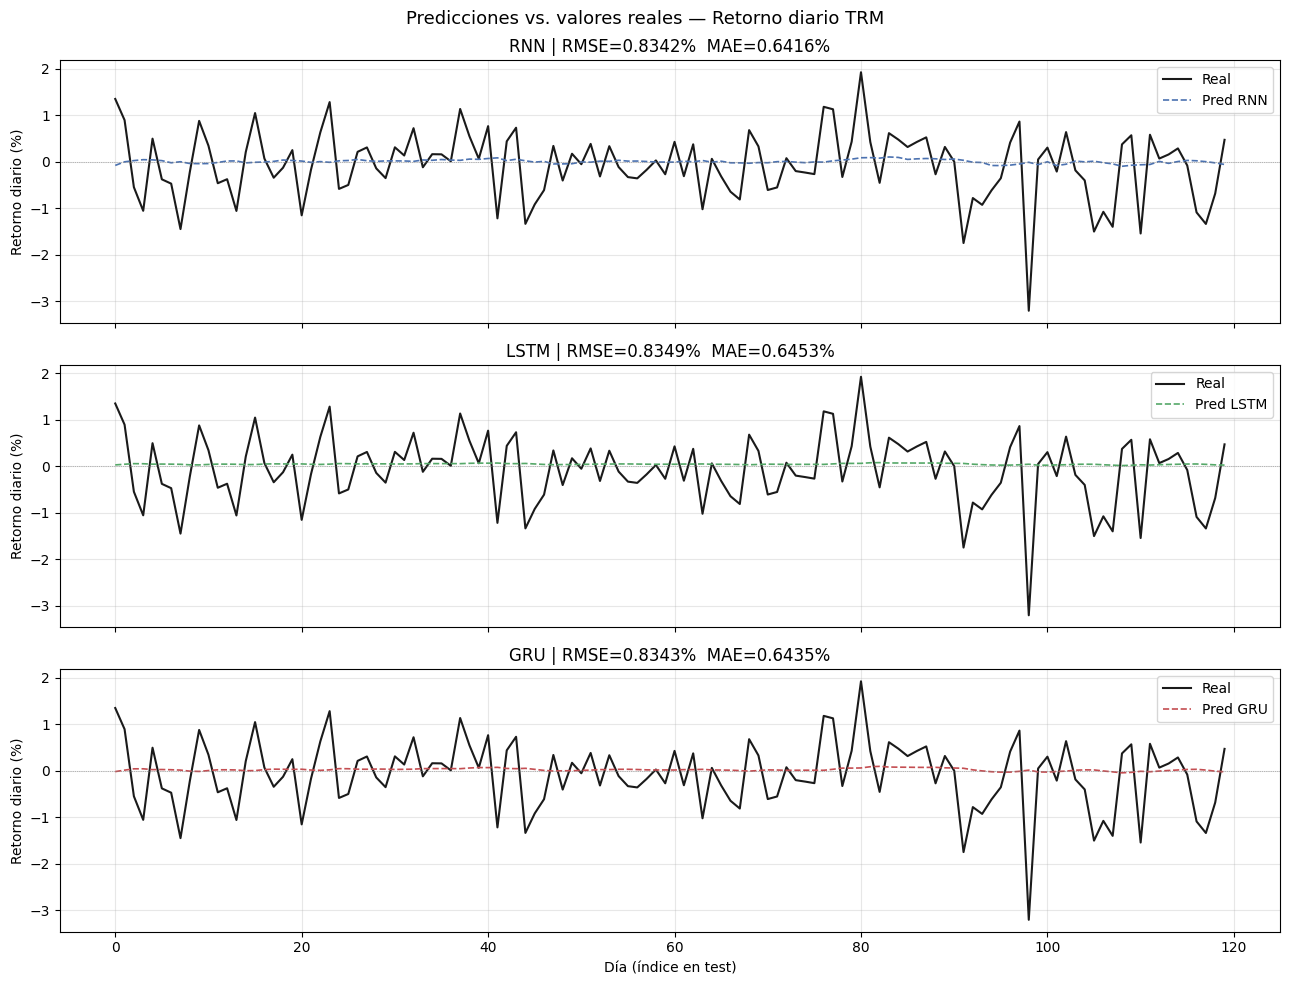

In [19]:
# Gráfica: predicciones vs. valores reales (últimos 120 días de test)
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, tipo in zip(axes, ["RNN", "LSTM", "GRU"]):
    pred, real = predicciones[tipo]
    n_mostrar  = 120
    ax.plot(real[-n_mostrar:], label="Real",
            color="#1a1a1a", linewidth=1.5)
    ax.plot(pred[-n_mostrar:], label=f"Pred {tipo}",
            color=colores[tipo], linewidth=1.2, linestyle="--")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
    ax.set_title(f"{tipo} | RMSE={metricas[tipo]['RMSE']:.4f}%  "
                 f"MAE={metricas[tipo]['MAE']:.4f}%")
    ax.set_ylabel("Retorno diario (%)")
    ax.legend(loc="upper right"); ax.grid(alpha=0.3)

axes[-1].set_xlabel("Día (índice en test)")
plt.suptitle("Predicciones vs. valores reales — Retorno diario TRM", fontsize=13)
plt.tight_layout(); plt.show()


## 8. Reconstrucción del nivel de TRM a partir de retornos predichos

Para conectar con el proyecto original, reconstruimos el nivel de la TRM
aplicando los retornos predichos sobre el último valor real conocido.
Esto permite visualizar la predicción en pesos, no en porcentajes.


Anclaje: 4089.72 pesos


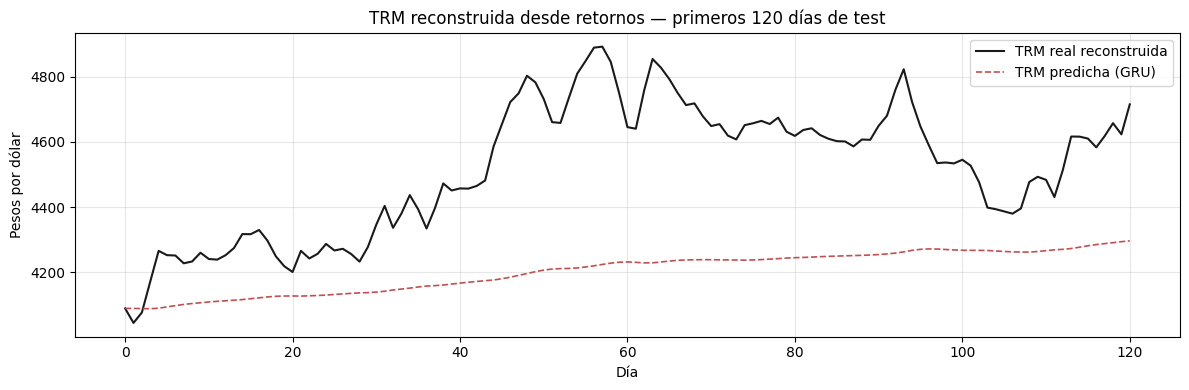

TRM predicha: 4089.72 → 4296.68
TRM real    : 4089.72 → 4714.85

Nota: reconstrucción acumulativa de primeros 120 días de test.
Para uso operativo, re-anclar al último precio real disponible.


In [20]:
# Reconstrucción del nivel TRM — primeros 120 días de test
fecha_inicio_test = df["fecha"].iloc[i_va]
ultimo_precio_val = df[df["fecha"] < fecha_inicio_test]["trm"].iloc[-1]
print(f"Anclaje: {ultimo_precio_val:.2f} pesos")

pred_ret, real_ret = predicciones["GRU"]

N = 120
trm_real_rec = [ultimo_precio_val]
trm_pred_rec = [ultimo_precio_val]

for i in range(N):
    trm_real_rec.append(trm_real_rec[-1] * (1 + real_ret[i][0] / 100))
    trm_pred_rec.append(trm_pred_rec[-1] * (1 + pred_ret[i][0] / 100))

plt.figure(figsize=(12, 4))
plt.plot(trm_real_rec, label="TRM real reconstruida",
         color="#1a1a1a", linewidth=1.5)
plt.plot(trm_pred_rec, label="TRM predicha (GRU)",
         color="#C44E52", linewidth=1.2, linestyle="--")
plt.title("TRM reconstruida desde retornos — primeros 120 días de test")
plt.ylabel("Pesos por dólar")
plt.xlabel("Día")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"TRM predicha: {trm_pred_rec[0]:.2f} → {trm_pred_rec[-1]:.2f}")
print(f"TRM real    : {trm_real_rec[0]:.2f} → {trm_real_rec[-1]:.2f}")
print("\nNota: reconstrucción acumulativa de primeros 120 días de test.")
print("Para uso operativo, re-anclar al último precio real disponible.")

**Nota metodológica:** la reconstrucción acumula errores pequeños día a
día, por lo que diverge en horizontes largos. Para alertas de corto plazo
(1–5 días), el error acumulado es manejable. Para horizontes más largos,
se re-ancla al último valor real disponible.


## 9. Guardar modelos

In [21]:
for tipo in ["RNN", "LSTM", "GRU"]:
    fname = f"centinela_fase2_{tipo.lower()}.pt"
    torch.save(resultados[tipo]["modelo"].state_dict(), fname)
    print(f"Guardado: {fname}")


Guardado: centinela_fase2_rnn.pt
Guardado: centinela_fase2_lstm.pt
Guardado: centinela_fase2_gru.pt


## 10. Resumen de la Rama B

**Datos:** TRM diaria (Superintendencia Financiera / Datos Abiertos Colombia),
6.307 retornos diarios desde enero 2000. Sin faltantes.

**Variable objetivo:** retorno porcentual diario de la TRM, en lugar del nivel
absoluto. Decisión justificada por la no-estacionariedad de la serie en nivel,
que causaba extrapolación severa en el período de test.

**Preprocesamiento:** MinMaxScaler ajustado solo en train, ventana deslizante de
30 días, partición cronológica 70/15/15.

**Arquitecturas:** RNN simple (referencia), LSTM y GRU, con 2 capas ocultas de
64 neuronas, Dropout 0.2, gradient clipping (max_norm=1.0) y early stopping
(paciencia=15 épocas).

**Métricas:** RMSE, MAE y MAPE sobre retornos desnormalizados (porcentajes reales).

**Desvanecimiento del gradiente:** evidenciado comparando la norma del gradiente
de la capa 0 entre RNN y LSTM durante el entrenamiento.

**Conexión con el proyecto:** la TRM es una de las variables que afecta el poder
adquisitivo del SMLV. Un aumento sostenido de la TRM presiona los precios de
bienes importados y erode el salario real, conectando esta Rama B con el
problema central de la Fase 1.

**Limitaciones:**
- Los retornos de la TRM son difíciles de predecir por su alta aleatoriedad
  (hipótesis de mercado eficiente).
- El modelo predice a un día vista; el horizonte corto es una fortaleza
  (menos incertidumbre) y una limitación (no anticipa tendencias).
- No se incluyen variables exógenas (petróleo, tasas Fed, etc.) que influyen
  en la TRM.
